# Demo subset EyePACS

Ruleaza rapid pe un subset mic pentru sanity check si overfit test inainte de antrenarea completa.

In [1]:
import os
import random
import glob
import gc
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
from tqdm.auto import tqdm
from PIL import Image

# ============================================================
# CONFIGURARE RULARE LOCALA CUDA
# ============================================================
# Variante locale: "cuda", "auto", "cpu". TPU este dezactivat in aceste notebook-uri.
ACCELERATOR = "cuda"
SEED = 42

def find_project_dir():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "Diabetic-Retinopathy-Classifier", *cwd.parents]
    for candidate in candidates:
        if (candidate / "datasets").exists() and (candidate / "Notebooks").exists():
            return candidate
        child = candidate / "Diabetic-Retinopathy-Classifier"
        if (child / "datasets").exists() and (child / "Notebooks").exists():
            return child
    raise FileNotFoundError(
        "Nu gasesc folderul Diabetic-Retinopathy-Classifier cu datasets/ si Notebooks/. "
        "Porneste notebook-ul din repo sau seteaza manual PROJECT_DIR."
    )

PROJECT_DIR = find_project_dir()
BASE_DIR = str(PROJECT_DIR / "datasets" / "originals" / "EyePACS")
CSV_PATH_ALL = str(Path(BASE_DIR) / "all_labels.csv")
OUT_DIR = str(PROJECT_DIR / "datasets" / "processed_by_me" / "local_notebook_outputs" / "processed_bg_224_demo_local")

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"BASE_DIR: {BASE_DIR}")
print(f"CSV_PATH_ALL: {CSV_PATH_ALL}")
print(f"OUT_DIR: {OUT_DIR}")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def select_device(accelerator="auto"):
    accelerator = accelerator.lower()
    if accelerator == "cuda" or (accelerator == "auto" and torch.cuda.is_available()):
        if not torch.cuda.is_available():
            raise RuntimeError("Ai ales CUDA, dar torch.cuda.is_available() este False.")
        torch.backends.cudnn.benchmark = True
        return torch.device("cuda"), False, None

    if accelerator == "cpu" or accelerator == "auto":
        return torch.device("cpu"), False, None

    raise ValueError("ACCELERATOR local invalid. Alege 'cuda', 'auto' sau 'cpu'.")

seed_everything(SEED)
device, IS_TPU, xm = select_device(ACCELERATOR)

print(f"Device curent: {device}")
print(f"CUDA disponibil: {torch.cuda.is_available()}")
if device.type == "cuda":
    print(f"GPU-uri disponibile: {torch.cuda.device_count()} | {torch.cuda.get_device_name(0)}")


# Modele separate pe stage.
# Stage 1: torchvision efficientnet_b3.
# Stage 2: timm inception_resnet_v2; daca lipseste timm, instaleaza-l cu: pip install timm
MODEL_STAGE1_NAME = "efficientnet_b3"
MODEL_STAGE2_NAME = "inception_resnet_v2"

# Seturi controlate pentru antrenare in demo.
STAGE1_SAMPLES_PER_BINARY_CLASS = 5000
STAGE2_SAMPLES_PER_CLASS = 2500
DEMO_EPOCHS = 10

PROJECT_DIR: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier
BASE_DIR: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS
CSV_PATH_ALL: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\EyePACS\all_labels.csv
OUT_DIR: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\local_notebook_outputs\processed_bg_224_demo_local
Device curent: cuda
CUDA disponibil: True
GPU-uri disponibile: 1 | NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
print("Se mapeaza datasetul complet...")

df = pd.read_csv(CSV_PATH_ALL)
print(f"Linii in all_labels.csv: {len(df)}")
print("Coloane CSV:", list(df.columns))

label_candidates = ['level', 'diagnosis', 'label', 'class', 'dr_level', 'retinopathy_grade']
image_candidates = ['image', 'image_id', 'id_code', 'filename', 'file_name', 'name']

label_col = next((col for col in label_candidates if col in df.columns), None)
image_col = next((col for col in image_candidates if col in df.columns), None)

if label_col is None:
    raise KeyError(
        "Nu gasesc coloana de eticheta. Coloane disponibile: "
        f"{list(df.columns)}. Redenumeste coloana de diagnostic in 'level' sau adaug-o in label_candidates."
    )
if image_col is None:
    raise KeyError(
        "Nu gasesc coloana cu numele imaginii. Coloane disponibile: "
        f"{list(df.columns)}. Redenumeste coloana imaginii in 'image' sau adaug-o in image_candidates."
    )

df = df.rename(columns={label_col: 'level', image_col: 'image'})
df['level'] = pd.to_numeric(df['level'], errors='coerce')
df = df.dropna(subset=['level']).copy()
df['level'] = df['level'].astype(int)
df['image_key'] = df['image'].astype(str).apply(lambda x: os.path.splitext(os.path.basename(x))[0])

toate_imaginile = glob.glob(os.path.join(BASE_DIR, '**', '*.*'), recursive=True)
toate_imaginile = [p for p in toate_imaginile if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
mapare_cai = {os.path.splitext(os.path.basename(p))[0]: p for p in toate_imaginile}

df['file_path'] = df['image_key'].map(mapare_cai)
df = df.dropna(subset=['file_path']).reset_index(drop=True)
df['original_file_path'] = df['file_path']

print("Curatam intrarile catre fisiere lipsa/corupte...")
indici_valizi = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Scanare integritate"):
    try:
        if os.path.getsize(row['file_path']) > 0:
            indici_valizi.append(idx)
    except OSError:
        pass

df = df.loc[indici_valizi].reset_index(drop=True)
df['is_diseased'] = df['level'].apply(lambda x: 0 if x == 0 else 1)
df['level_stage2'] = df['level'].apply(lambda x: x - 1 if x > 0 else -1)

print(f"Imagini valide fizic: {len(df)}")
print("Distributie 5 clase in datasetul mapat:")
print(df['level'].value_counts().sort_index())
print("Distributie binara Stage 1 in datasetul mapat:")
print(df['is_diseased'].value_counts().sort_index())

Se mapeaza datasetul complet...
Linii in all_labels.csv: 88700
Coloane CSV: ['image', 'level', 'Usage']
Curatam intrarile catre fisiere lipsa/corupte...


Scanare integritate:   0%|          | 0/88700 [00:00<?, ?it/s]

Imagini valide fizic: 88700
Distributie 5 clase in datasetul mapat:
level
0    65342
1     6205
2    13152
3     2087
4     1914
Name: count, dtype: int64
Distributie binara Stage 1 in datasetul mapat:
is_diseased
0    65342
1    23358
Name: count, dtype: int64


In [3]:
print("=== PREPROCESARE OFFLINE BEN GRAHAM + CLAHE ===")

cv2.setNumThreads(0)
DEMO_OUT_DIR = OUT_DIR + '_demo'
os.makedirs(DEMO_OUT_DIR, exist_ok=True)

def process_and_save(args):
    img_path, image_id = args
    out_path = os.path.join(DEMO_OUT_DIR, f"{image_id}.jpg")
    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        return out_path

    try:
        img = cv2.imread(img_path)
        if img is None:
            return None

        size = 224
        img_resized = cv2.resize(img, (size, size))
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

        _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
        kernel_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_clean)
        contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            cv2.imwrite(out_path, img_resized)
            return out_path

        contur_ochi = max(contours, key=cv2.contourArea)
        masca_ochi = np.zeros((size, size), dtype=np.uint8)
        cv2.drawContours(masca_ochi, [contur_ochi], -1, 255, thickness=cv2.FILLED)

        kernel_eroziune = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
        masca_ochi = cv2.erode(masca_ochi, kernel_eroziune, iterations=1)

        sigmaX = size / 30.0
        blur = cv2.GaussianBlur(gray, (0, 0), sigmaX)
        ben_graham_gray = cv2.addWeighted(gray, 4, blur, -4, 128)

        masca_exterior = cv2.bitwise_not(masca_ochi)
        dist = cv2.distanceTransform(masca_exterior, cv2.DIST_L2, 5)
        halo_width = 35.0
        rezultat_final = np.full((size, size), 128.0, dtype=np.float32)

        halo_mask = (dist > 0) & (dist <= halo_width)
        rezultat_final[halo_mask] = 128.0 * (dist[halo_mask] / halo_width)
        rezultat_final[masca_ochi == 255] = ben_graham_gray[masca_ochi == 255]

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        rezultat_final = clahe.apply(rezultat_final.astype(np.uint8))
        rezultat_final_3c = cv2.cvtColor(rezultat_final, cv2.COLOR_GRAY2BGR)
        cv2.imwrite(out_path, rezultat_final_3c)
        return out_path
    except Exception:
        return None

tasks = [(row['original_file_path'], row['image_key']) for _, row in df.iterrows()]
rezultate_finale = []

BATCH_SIZE_MP = 5000
WORKERS = min(8, os.cpu_count() or 1)

print(f"Procesam {len(tasks)} imagini in {DEMO_OUT_DIR}...")
for i in range(0, len(tasks), BATCH_SIZE_MP):
    batch_tasks = tasks[i : i + BATCH_SIZE_MP]
    with ThreadPoolExecutor(max_workers=WORKERS) as executor:
        batch_rezultate = list(tqdm(
            executor.map(process_and_save, batch_tasks),
            total=len(batch_tasks),
            desc=f"Batch {i // BATCH_SIZE_MP + 1}"
        ))
    rezultate_finale.extend(batch_rezultate)
    del batch_tasks, batch_rezultate
    gc.collect()

df['processed_path'] = rezultate_finale
df = df.dropna(subset=['processed_path']).reset_index(drop=True)
df['file_path'] = df['processed_path']
df = df.drop(columns=['processed_path'])

df_train_full, df_val = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['level']
)
df_train_full = df_train_full.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

def sample_exact(dataframe, n, random_state, label):
    replace = len(dataframe) < n
    if replace:
        print(f"Atentie: {label} are doar {len(dataframe)} imagini; folosesc sample cu replacement pana la {n}.")
    return dataframe.sample(n=n, replace=replace, random_state=random_state)

df_train_s1_no_dr = sample_exact(
    df_train_full[df_train_full['is_diseased'] == 0],
    STAGE1_SAMPLES_PER_BINARY_CLASS,
    SEED,
    "Stage 1 No DR"
)
df_train_s1_dr = sample_exact(
    df_train_full[df_train_full['is_diseased'] == 1],
    STAGE1_SAMPLES_PER_BINARY_CLASS,
    SEED + 1,
    "Stage 1 DR"
)
df_train_s1 = pd.concat([df_train_s1_no_dr, df_train_s1_dr], ignore_index=True)
df_train_s1 = df_train_s1.sample(frac=1, random_state=SEED).reset_index(drop=True)

stage2_parts = []
for level_stage2 in range(4):
    df_level = df_train_full[df_train_full['level_stage2'] == level_stage2]
    stage2_parts.append(sample_exact(
        df_level,
        STAGE2_SAMPLES_PER_CLASS,
        SEED + 10 + level_stage2,
        f"Stage 2 clasa {level_stage2}"
    ))
df_train_s2 = pd.concat(stage2_parts, ignore_index=True)
df_train_s2 = df_train_s2.sample(frac=1, random_state=SEED).reset_index(drop=True)

df_val_stage2 = df_val[df_val['is_diseased'] == 1].reset_index(drop=True)

print(f"Gata: {len(df)} imagini procesate.")
print("\n=== SPLITURI NATURALE DUPA PREPROCESARE ===")
print(f"Train full: {len(df_train_full)} | Val full: {len(df_val)}")
print("Train full - distributie 5 clase:")
print(df_train_full['level'].value_counts().sort_index())
print("Val full - distributie 5 clase:")
print(df_val['level'].value_counts().sort_index())
print("Train full - distributie binara Stage 1:")
print(df_train_full['is_diseased'].value_counts().sort_index())
print("Val full - distributie binara Stage 1:")
print(df_val['is_diseased'].value_counts().sort_index())

print("\n=== SETURI CONTROLATE DE ANTRENARE ===")
print(f"Stage 1 train controlat: {len(df_train_s1)} | Val Stage 1: {len(df_val)}")
print(df_train_s1['is_diseased'].value_counts().sort_index())
print(f"Stage 2 train controlat: {len(df_train_s2)} | Val Stage 2: {len(df_val_stage2)}")
print(df_train_s2['level_stage2'].value_counts().sort_index())
print("Val Stage 2 - distributie:")
print(df_val_stage2['level_stage2'].value_counts().sort_index())

=== PREPROCESARE OFFLINE BEN GRAHAM + CLAHE ===
Procesam 88700 imagini in B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\local_notebook_outputs\processed_bg_224_demo_local_demo...


Batch 1:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 2:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 3:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 4:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Batch 15:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 16:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 17:   0%|          | 0/5000 [00:00<?, ?it/s]

Batch 18:   0%|          | 0/3700 [00:00<?, ?it/s]

Atentie: Stage 2 clasa 2 are doar 1670 imagini; folosesc sample cu replacement pana la 2500.
Atentie: Stage 2 clasa 3 are doar 1531 imagini; folosesc sample cu replacement pana la 2500.
Gata: 88699 imagini procesate.

=== SPLITURI NATURALE DUPA PREPROCESARE ===
Train full: 70959 | Val full: 17740
Train full - distributie 5 clase:
level
0    52273
1     4964
2    10521
3     1670
4     1531
Name: count, dtype: int64
Val full - distributie 5 clase:
level
0    13068
1     1241
2     2631
3      417
4      383
Name: count, dtype: int64
Train full - distributie binara Stage 1:
is_diseased
0    52273
1    18686
Name: count, dtype: int64
Val full - distributie binara Stage 1:
is_diseased
0    13068
1     4672
Name: count, dtype: int64

=== SETURI CONTROLATE DE ANTRENARE ===
Stage 1 train controlat: 10000 | Val Stage 1: 17740
is_diseased
0    5000
1    5000
Name: count, dtype: int64
Stage 2 train controlat: 10000 | Val Stage 2: 4672
level_stage2
0    2500
1    2500
2    2500
3    2500
Name: co

In [4]:
print("=== DATASETS SI DATALOADERS ===")

import sys

LOCAL_NOTEBOOK_DIR = PROJECT_DIR / "Notebooks" / "Main" / "Local"
if str(LOCAL_NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(LOCAL_NOTEBOOK_DIR))

from local_retinopathy_dataset import RetinopathyDataset

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

BATCH_SIZE = 32
NUM_WORKERS = 4
PIN_MEMORY = (device.type == "cuda")

dataloader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "persistent_workers": NUM_WORKERS > 0,
}
if NUM_WORKERS > 0:
    dataloader_kwargs["prefetch_factor"] = 2

loader_train_s1 = DataLoader(
    RetinopathyDataset(df_train_s1, transform_train),
    shuffle=True,
    **dataloader_kwargs
)
loader_val_s1 = DataLoader(
    RetinopathyDataset(df_val, transform_val),
    shuffle=False,
    **dataloader_kwargs
)
loader_train_s2 = DataLoader(
    RetinopathyDataset(df_train_s2, transform_train, is_stage2=True),
    shuffle=True,
    **dataloader_kwargs
)
loader_val_s2 = DataLoader(
    RetinopathyDataset(df_val_stage2, transform_val, is_stage2=True),
    shuffle=False,
    **dataloader_kwargs
)

print(f"Batch-uri Stage 1: train={len(loader_train_s1)} | val={len(loader_val_s1)}")
print(f"Batch-uri Stage 2: train={len(loader_train_s2)} | val={len(loader_val_s2)}")
print("\nNumar imagini folosite de DataLoader:")
print(f"Stage 1 train: {len(loader_train_s1.dataset)} | Stage 1 val: {len(loader_val_s1.dataset)}")
print(f"Stage 2 train: {len(loader_train_s2.dataset)} | Stage 2 val: {len(loader_val_s2.dataset)}")

print("\nVerificare rapida DataLoader: incerc sa citesc primul batch...")
sample_images, sample_labels = next(iter(loader_train_s1))
print(f"Primul batch Stage 1: imagini={tuple(sample_images.shape)}, etichete={tuple(sample_labels.shape)}")
sample_images, sample_labels = next(iter(loader_train_s2))
print(f"Primul batch Stage 2: imagini={tuple(sample_images.shape)}, etichete={tuple(sample_labels.shape)}")
del sample_images, sample_labels

=== DATASETS SI DATALOADERS ===
Batch-uri Stage 1: train=313 | val=555
Batch-uri Stage 2: train=313 | val=146

Numar imagini folosite de DataLoader:
Stage 1 train: 10000 | Stage 1 val: 17740
Stage 2 train: 10000 | Stage 2 val: 4672

Verificare rapida DataLoader: incerc sa citesc primul batch...
Primul batch Stage 1: imagini=(32, 3, 224, 224), etichete=(32,)
Primul batch Stage 2: imagini=(32, 3, 224, 224), etichete=(32,)


=== VERIFICARE VIZUALA: PREPROCESARE SI AUGMENTARE ===


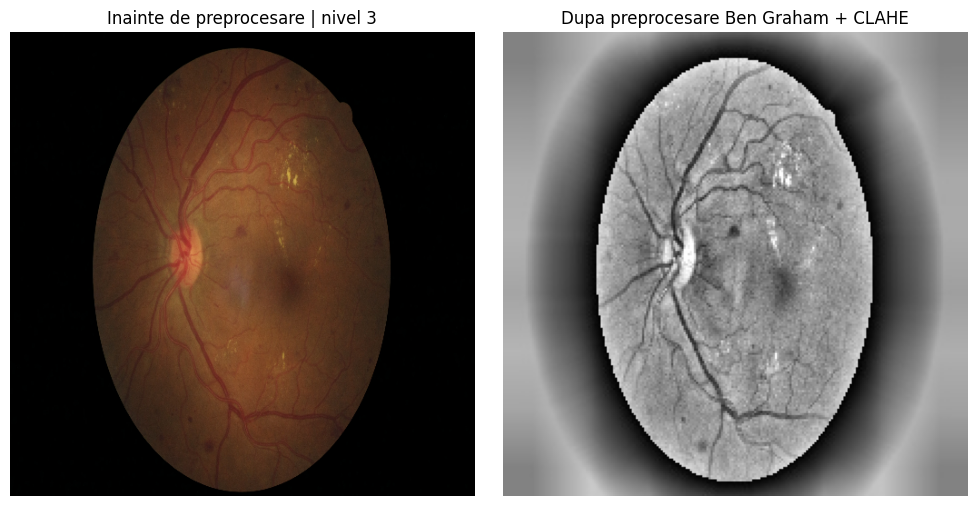

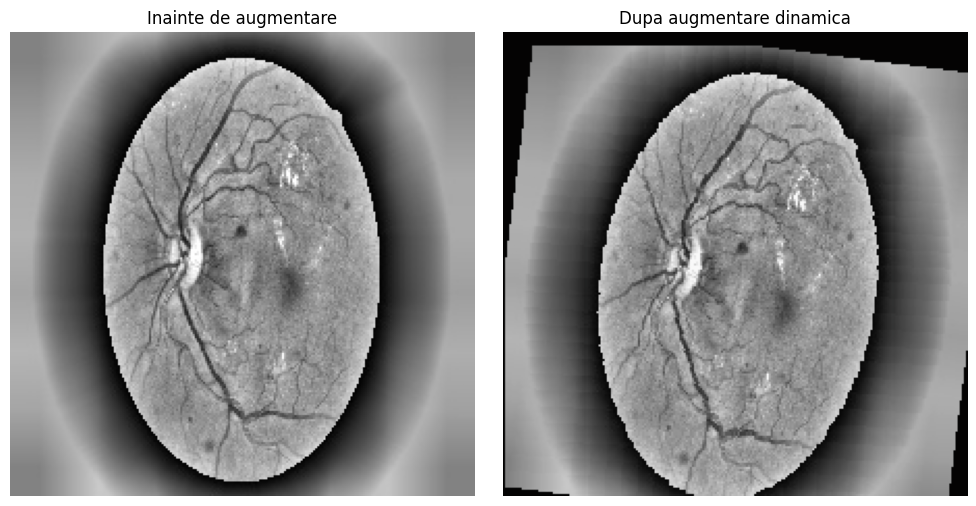

In [5]:
print("=== VERIFICARE VIZUALA: PREPROCESARE SI AUGMENTARE ===")

def show_image_pair(img_a, img_b, title_a, title_b, figsize=(10, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(img_a)
    axes[0].set_title(title_a)
    axes[0].axis("off")
    axes[1].imshow(img_b)
    axes[1].set_title(title_b)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

def tensor_to_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor.detach().cpu() * std + mean
    tensor = tensor.clamp(0, 1)
    return tensor.permute(1, 2, 0).numpy()

sample_row = df_train_s1.sample(1, random_state=SEED).iloc[0]
img_originala = Image.open(sample_row['original_file_path']).convert("RGB")
img_procesata = Image.open(sample_row['file_path']).convert("RGB")

show_image_pair(
    img_originala,
    img_procesata,
    f"Inainte de preprocesare | nivel {sample_row['level']}",
    "Dupa preprocesare Ben Graham + CLAHE"
)

img_procesata_pil = Image.open(sample_row['file_path']).convert("RGB")
img_fara_aug = tensor_to_image(transform_val(img_procesata_pil))
img_cu_aug = tensor_to_image(transform_train(img_procesata_pil))

show_image_pair(
    img_fara_aug,
    img_cu_aug,
    "Inainte de augmentare",
    "Dupa augmentare dinamica"
)

In [6]:
print("=== MODELE, LOSS, OPTIMIZER, SCHEDULER ===")

EPOCHS = DEMO_EPOCHS
LEARNING_RATE_STAGE1 = 7e-5
LEARNING_RATE_STAGE2 = 5e-5
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30

def replace_torchvision_classifier(model, num_classes):
    if hasattr(model, "fc"):
        num_ftrs = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(p=DROPOUT), nn.Linear(num_ftrs, num_classes))
    elif hasattr(model, "classifier"):
        classifier = model.classifier
        if isinstance(classifier, nn.Sequential):
            in_features = None
            for layer in reversed(classifier):
                if isinstance(layer, nn.Linear):
                    in_features = layer.in_features
                    break
            if in_features is None:
                raise ValueError("Nu gasesc strat Linear in classifier.")
            model.classifier = nn.Sequential(nn.Dropout(p=DROPOUT), nn.Linear(in_features, num_classes))
        elif isinstance(classifier, nn.Linear):
            model.classifier = nn.Sequential(nn.Dropout(p=DROPOUT), nn.Linear(classifier.in_features, num_classes))
        else:
            raise ValueError(f"Classifier necunoscut pentru {type(model).__name__}.")
    else:
        raise ValueError(f"Nu stiu sa inlocuiesc head-ul pentru {type(model).__name__}.")
    return model

def build_torchvision_model(num_classes, model_name):
    model_name = model_name.lower()

    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    elif model_name == "efficientnet_b2":
        model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
    elif model_name == "efficientnet_b3":
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    elif model_name == "mobilenet_v3_large":
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
    else:
        return None

    return replace_torchvision_classifier(model, num_classes)

def build_timm_model(num_classes, model_name):
    try:
        import timm
    except ModuleNotFoundError as exc:
        raise RuntimeError(
            f"Modelul '{model_name}' necesita pachetul timm. "
            "In Kaggle ruleaza o celula cu: !pip install timm"
        ) from exc

    return timm.create_model(model_name, pretrained=True, num_classes=num_classes, drop_rate=DROPOUT)

def build_model(num_classes, model_name):
    model = build_torchvision_model(num_classes, model_name)
    if model is None:
        model = build_timm_model(num_classes, model_name)

    model = model.to(device)

    if device.type == "cuda" and torch.cuda.device_count() > 1:
        print(f"Folosim DataParallel pe {torch.cuda.device_count()} GPU-uri pentru {model_name}.")
        model = nn.DataParallel(model)
    return model

print(f"Stage 1 model: {MODEL_STAGE1_NAME}")
print(f"Stage 2 model: {MODEL_STAGE2_NAME}")
model_stage1 = build_model(num_classes=1, model_name=MODEL_STAGE1_NAME)
model_stage2 = build_model(num_classes=4, model_name=MODEL_STAGE2_NAME)

neg_count = int((df_train_s1['is_diseased'] == 0).sum())
pos_count = int((df_train_s1['is_diseased'] == 1).sum())
pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32, device=device)
criterion_s1 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

stage2_counts = df_train_s2['level_stage2'].value_counts().reindex(range(4), fill_value=1).sort_index()
class_weights = len(df_train_s2) / (4.0 * torch.tensor(stage2_counts.values, dtype=torch.float32))
criterion_s2 = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.05)

optimizer_s1 = optim.AdamW(model_stage1.parameters(), lr=LEARNING_RATE_STAGE1, weight_decay=WEIGHT_DECAY)
optimizer_s2 = optim.AdamW(model_stage2.parameters(), lr=LEARNING_RATE_STAGE2, weight_decay=WEIGHT_DECAY)

scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_s1, mode='max', factor=0.5, patience=1, min_lr=1e-6)
scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_s2, mode='max', factor=0.5, patience=1, min_lr=1e-6)

print(f"Stage 1 pos_weight: {pos_weight.item():.4f}")
print("Stage 2 class weights:", class_weights.tolist())

=== MODELE, LOSS, OPTIMIZER, SCHEDULER ===
Stage 1 model: efficientnet_b3
Stage 2 model: inception_resnet_v2
Stage 1 pos_weight: 1.0000
Stage 2 class weights: [1.0, 1.0, 1.0, 1.0]


In [ ]:
print("=== MOTOR DE ANTRENARE CUDA/TPU ===")

def _state_dict_cpu(model):
    state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
    return {k: v.detach().cpu().clone() for k, v in state.items()}

def _load_state_dict(model, state):
    target = model.module if isinstance(model, nn.DataParallel) else model
    target.load_state_dict(state)

def optimizer_step(optimizer):
    optimizer.step()

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    epochs=10,
    is_binary=True,
    patience=4,
    min_delta=1e-4
):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_qwk': []}
    best_score = -float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_preds, train_targets = 0.0, [], []

        for images, labels in tqdm(train_loader, desc=f"Epoca {epoch + 1}/{epochs} [TRAIN]"):
            images = images.to(device, non_blocking=PIN_MEMORY)
            labels = labels.to(device, non_blocking=PIN_MEMORY)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            if is_binary:
                outputs = outputs.squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_step(optimizer)

            train_loss += loss.item() * images.size(0)
            if is_binary:
                preds = (torch.sigmoid(outputs) > 0.5).long()
            else:
                preds = torch.argmax(outputs, dim=1)

            train_preds.extend(preds.detach().cpu().numpy())
            train_targets.extend(labels.detach().cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_targets, train_preds)

        model.eval()
        val_loss, val_preds, val_targets = 0.0, [], []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoca {epoch + 1}/{epochs} [VAL]"):
                images = images.to(device, non_blocking=PIN_MEMORY)
                labels = labels.to(device, non_blocking=PIN_MEMORY)
                outputs = model(images)
                if is_binary:
                    outputs = outputs.squeeze(1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                if is_binary:
                    preds = (torch.sigmoid(outputs) > 0.5).long()
                else:
                    preds = torch.argmax(outputs, dim=1)

                val_preds.extend(preds.detach().cpu().numpy())
                val_targets.extend(labels.detach().cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_targets, val_preds)
        val_qwk = cohen_kappa_score(val_targets, val_preds, weights='quadratic')

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_qwk)
            else:
                scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"Epoca {epoch + 1:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | "
            f"T_Acc: {train_acc:.4f} | V_Acc: {val_acc:.4f} | Val QWK: {val_qwk:.4f} | LR: {current_lr:.2e}"
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_qwk'].append(val_qwk)

        if val_qwk > best_score + min_delta:
            best_score = val_qwk
            best_state = _state_dict_cpu(model)
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping: QWK nu s-a imbunatatit timp de {patience} epoci.")
                break

    if best_state is not None:
        _load_state_dict(model, best_state)
        print(f"Am restaurat cel mai bun model dupa Val QWK: {best_score:.4f}")

    return history

=== MOTOR DE ANTRENARE CUDA/TPU ===


In [ ]:
print("\n" + "=" * 50)
print("ANTRENARE STAGE 1: detectie boala")
print("=" * 50)
history_s1 = train_model(
    model_stage1,
    loader_train_s1,
    loader_val_s1,
    criterion_s1,
    optimizer_s1,
    scheduler=scheduler_s1,
    epochs=10,
    is_binary=True,
    patience=7
)

# print("\n" + "=" * 50)
# print("ANTRENARE STAGE 2: severitate 1-4")
# print("=" * 50)
# history_s2 = train_model(
#     model_stage2,
#     loader_train_s2,
#     loader_val_s2,
#     criterion_s2,
#     optimizer_s2,
#     scheduler=scheduler_s2,
#     epochs=10,
#     is_binary=False,
#     patience=7
# )


ANTRENARE STAGE 1: detectie boala


Epoca 1/10 [TRAIN]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoca 1/10 [VAL]:   0%|          | 0/555 [00:08<?, ?it/s]

Epoca 01 | TL: 0.6641 | VL: 0.5753 | T_Acc: 0.5882 | V_Acc: 0.7424 | Val QWK: 0.2855 | LR: 7.00e-05


Epoca 2/10 [TRAIN]:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoca 8/10 [VAL]:   0%|          | 0/146 [00:00<?, ?it/s]

Epoca 08 | TL: 0.4585 | VL: 4.2396 | T_Acc: 0.8783 | V_Acc: 0.3906 | Val QWK: 0.3741 | LR: 6.25e-06


Epoca 9/10 [TRAIN]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoca 9/10 [VAL]:   0%|          | 0/146 [00:00<?, ?it/s]

Epoca 09 | TL: 0.4335 | VL: 7.4096 | T_Acc: 0.8936 | V_Acc: 0.3731 | Val QWK: 0.3436 | LR: 6.25e-06
Early stopping: QWK nu s-a imbunatatit timp de 7 epoci.
Am restaurat cel mai bun model dupa Val QWK: 0.5435


## Grafice si evaluare

=== EVALUARE DEMO: GRAFICE, RAPOARTE, CONFUSION MATRIX ===


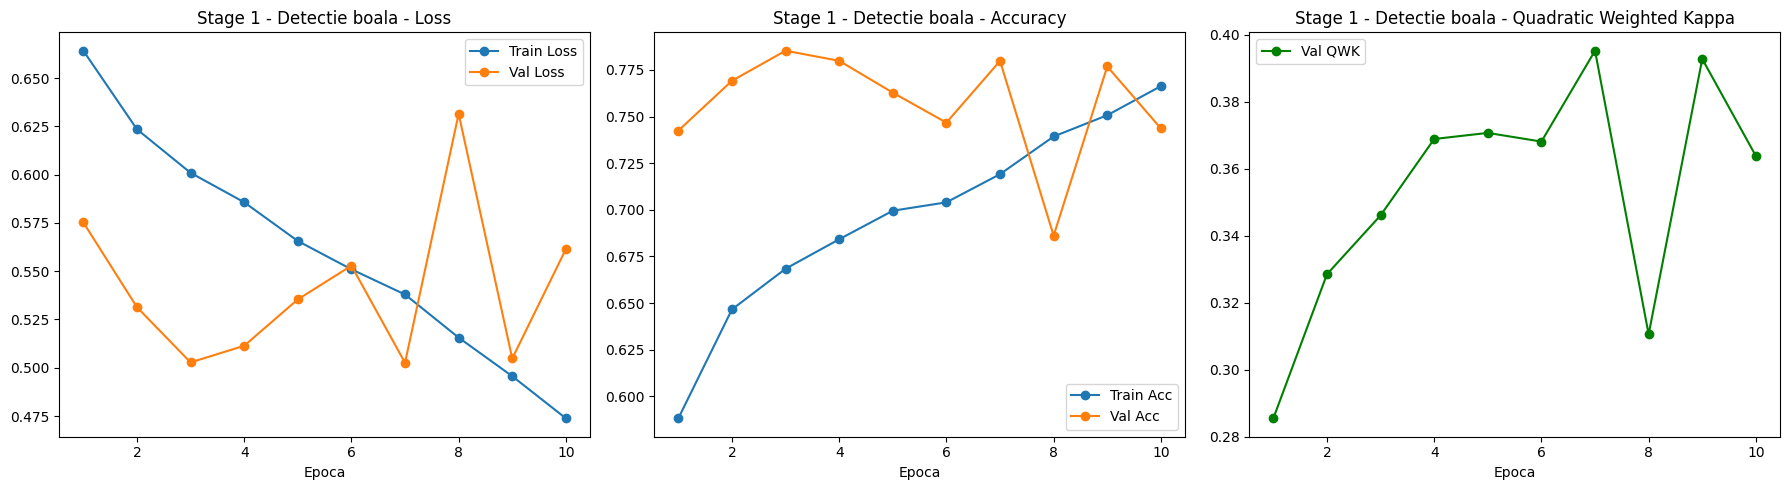

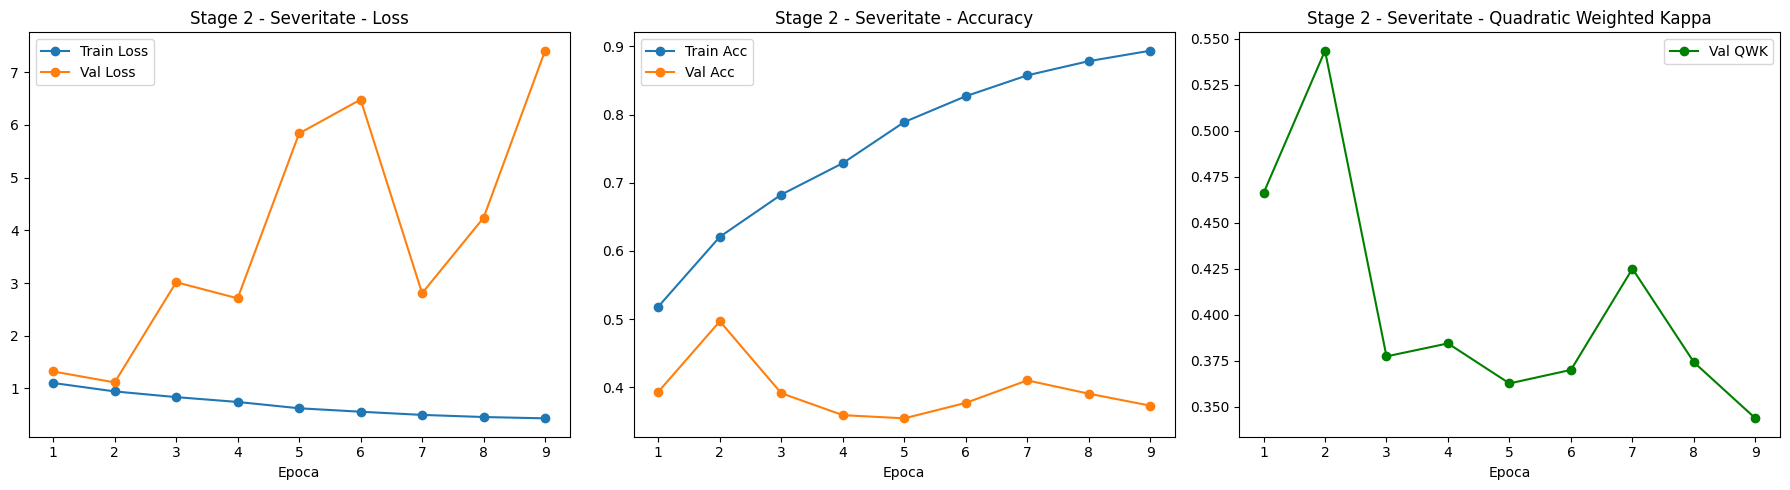

Predictii validare:   0%|          | 0/555 [00:00<?, ?it/s]


Stage 1: No DR vs DR
Accuracy: 0.7798 | QWK: 0.3952
              precision    recall  f1-score   support

       No DR       0.83      0.88      0.86     13068
          DR       0.60      0.49      0.54      4672

    accuracy                           0.78     17740
   macro avg       0.71      0.69      0.70     17740
weighted avg       0.77      0.78      0.77     17740



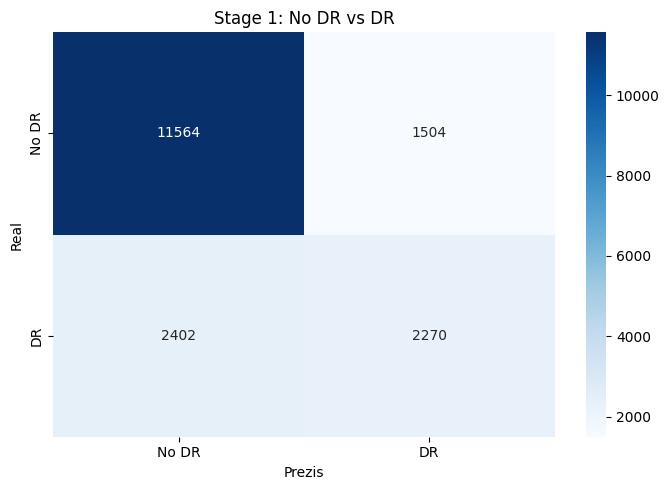

Predictii validare:   0%|          | 0/146 [00:00<?, ?it/s]


Stage 2: Severitate DR
Accuracy: 0.4968 | QWK: 0.5435
               precision    recall  f1-score   support

         Mild       0.47      0.78      0.58      1241
     Moderate       0.73      0.33      0.46      2631
       Severe       0.28      0.56      0.38       417
Proliferative       0.43      0.65      0.52       383

     accuracy                           0.50      4672
    macro avg       0.48      0.58      0.48      4672
 weighted avg       0.60      0.50      0.49      4672



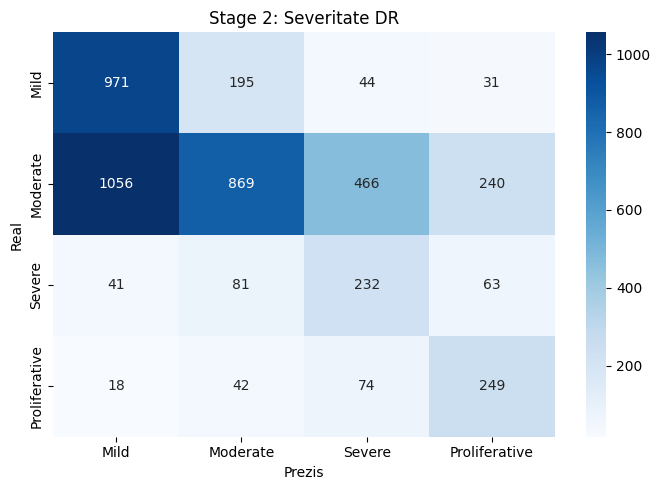

In [9]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("=== EVALUARE DEMO: GRAFICE, RAPOARTE, CONFUSION MATRIX ===")

def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs, history['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], marker='o', label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoca')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], marker='o', label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], marker='o', label='Val Acc')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoca')
    axes[1].legend()

    axes[2].plot(epochs, history['val_qwk'], marker='o', color='green', label='Val QWK')
    axes[2].set_title(f'{title} - Quadratic Weighted Kappa')
    axes[2].set_xlabel('Epoca')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

def collect_predictions(model, loader, is_binary):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predictii validare"):
            images = images.to(device, non_blocking=PIN_MEMORY)
            outputs = model(images)

            if is_binary:
                outputs = outputs.squeeze(1)
                preds = (torch.sigmoid(outputs) > 0.5).long()
            else:
                preds = torch.argmax(outputs, dim=1)

            y_pred.extend(preds.detach().cpu().numpy())
            y_true.extend(labels.numpy())

    return np.array(y_true), np.array(y_pred)

def evaluate_model(model, loader, is_binary, class_names, title):
    y_true, y_pred = collect_predictions(model, loader, is_binary=is_binary)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{title}")
    print(f"Accuracy: {acc:.4f} | QWK: {qwk:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Prezis')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

plot_history(history_s1, "Stage 1 - Detectie boala")
plot_history(history_s2, "Stage 2 - Severitate")

evaluate_model(
    model_stage1,
    loader_val_s1,
    is_binary=True,
    class_names=['No DR', 'DR'],
    title='Stage 1: No DR vs DR'
)

evaluate_model(
    model_stage2,
    loader_val_s2,
    is_binary=False,
    class_names=['Mild', 'Moderate', 'Severe', 'Proliferative'],
    title='Stage 2: Severitate DR'
)

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("=== EVALUARE DEMO: GRAFICE, RAPOARTE, CONFUSION MATRIX ===")

def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs, history['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], marker='o', label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoca')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], marker='o', label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], marker='o', label='Val Acc')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoca')
    axes[1].legend()

    axes[2].plot(epochs, history['val_qwk'], marker='o', color='green', label='Val QWK')
    axes[2].set_title(f'{title} - Quadratic Weighted Kappa')
    axes[2].set_xlabel('Epoca')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

def collect_predictions(model, loader, is_binary):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Predictii validare"):
            images = images.to(device, non_blocking=PIN_MEMORY)
            outputs = model(images)

            if is_binary:
                outputs = outputs.squeeze(1)
                preds = (torch.sigmoid(outputs) > 0.5).long()
            else:
                preds = torch.argmax(outputs, dim=1)

            y_pred.extend(preds.detach().cpu().numpy())
            y_true.extend(labels.numpy())

    return np.array(y_true), np.array(y_pred)

def evaluate_model(model, loader, is_binary, class_names, title):
    y_true, y_pred = collect_predictions(model, loader, is_binary=is_binary)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    acc = accuracy_score(y_true, y_pred)

    print(f"\n{title}")
    print(f"Accuracy: {acc:.4f} | QWK: {qwk:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Prezis')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

plot_history(history_s1, "Stage 1 - Detectie boala")
plot_history(history_s2, "Stage 2 - Severitate")

evaluate_model(
    model_stage1,
    loader_val_s1,
    is_binary=True,
    class_names=['No DR', 'DR'],
    title='Stage 1: No DR vs DR'
)

evaluate_model(
    model_stage2,
    loader_val_s2,
    is_binary=False,
    class_names=['Mild', 'Moderate', 'Severe', 'Proliferative'],
    title='Stage 2: Severitate DR'
)

## Inferenta

=== INFERENTA DEMO PE IMAGINI DIN VALIDARE ===
----------------------------------------------------------------------
Imagine: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\local_notebook_outputs\processed_bg_224_demo_local_demo\792_right.jpg
Real: No DR / nivel 0


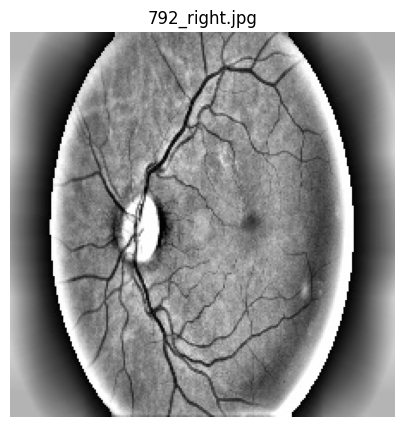

Predictie: DR nivel 1 - Mild
Probabilitate DR Stage 1: 0.6297
Probabilitati Stage 2 [Mild, Moderate, Severe, Proliferative]:
[0.5131 0.4101 0.0605 0.0163]
----------------------------------------------------------------------
Imagine: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\local_notebook_outputs\processed_bg_224_demo_local_demo\24199_left.jpg
Real: No DR / nivel 0


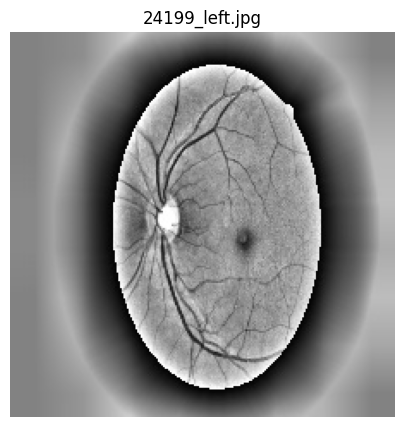

Predictie: No DR / nivel 0
Probabilitate DR Stage 1: 0.1728
----------------------------------------------------------------------
Imagine: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\local_notebook_outputs\processed_bg_224_demo_local_demo\35357_right.jpg
Real: No DR / nivel 0


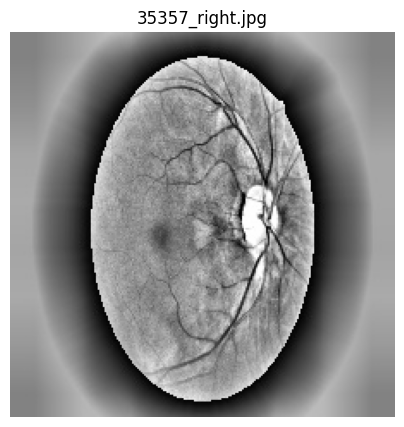

Predictie: No DR / nivel 0
Probabilitate DR Stage 1: 0.4426
----------------------------------------------------------------------
Imagine: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\local_notebook_outputs\processed_bg_224_demo_local_demo\4621_right.jpg
Real: DR nivel 2 - Moderate


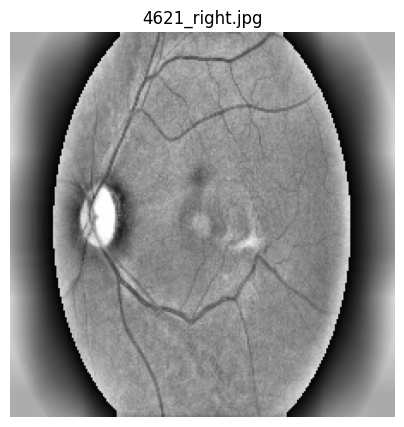

Predictie: No DR / nivel 0
Probabilitate DR Stage 1: 0.1434
----------------------------------------------------------------------
Imagine: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\local_notebook_outputs\processed_bg_224_demo_local_demo\18346_right.jpg
Real: No DR / nivel 0


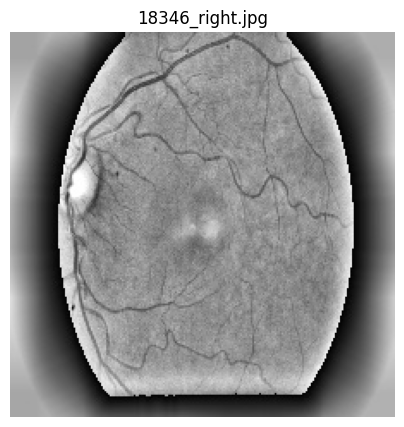

Predictie: No DR / nivel 0
Probabilitate DR Stage 1: 0.3049
----------------------------------------------------------------------
Imagine: B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\local_notebook_outputs\processed_bg_224_demo_local_demo\31844_right.jpg
Real: No DR / nivel 0


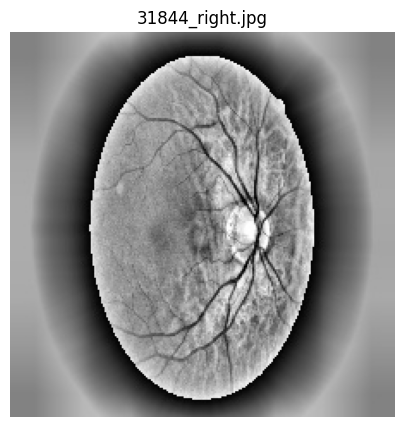

Predictie: No DR / nivel 0
Probabilitate DR Stage 1: 0.2184


In [11]:
print("=== INFERENTA DEMO PE IMAGINI DIN VALIDARE ===")

def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model

def describe_truth(row):
    if int(row['is_diseased']) == 0:
        return "No DR / nivel 0"
    names = {
        1: "Mild",
        2: "Moderate",
        3: "Severe",
        4: "Proliferative"
    }
    level = int(row['level'])
    return f"DR nivel {level} - {names.get(level, 'necunoscut')}"

def predict_retina(image_path, model_s1, model_s2, transform, threshold=0.5, show_image=True):
    image = Image.open(image_path).convert("RGB")

    if show_image:
        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(os.path.basename(image_path))
        plt.show()

    x = transform(image).unsqueeze(0).to(device)
    model_s1.eval()
    model_s2.eval()

    with torch.no_grad():
        out_s1 = model_s1(x).squeeze(1)
        prob_dr = torch.sigmoid(out_s1).item()

        if prob_dr < threshold:
            return {
                "prob_dr": prob_dr,
                "pred_level": 0,
                "pred_text": "No DR / nivel 0"
            }

        out_s2 = model_s2(x)
        probs_s2 = torch.softmax(out_s2, dim=1)[0].detach().cpu().numpy()
        pred_stage2 = int(np.argmax(probs_s2))
        pred_level = pred_stage2 + 1
        names = ['Mild', 'Moderate', 'Severe', 'Proliferative']

        return {
            "prob_dr": prob_dr,
            "stage2_probs": probs_s2,
            "pred_level": pred_level,
            "pred_text": f"DR nivel {pred_level} - {names[pred_stage2]}"
        }

def run_random_inference_examples(n=6, threshold=0.5):
    sample_df = df_val.sample(n=min(n, len(df_val)), random_state=SEED).reset_index(drop=True)

    for idx, row in sample_df.iterrows():
        print("-" * 70)
        print(f"Imagine: {row['file_path']}")
        print(f"Real: {describe_truth(row)}")

        result = predict_retina(
            row['file_path'],
            model_stage1,
            model_stage2,
            transform_val,
            threshold=threshold,
            show_image=True
        )

        print(f"Predictie: {result['pred_text']}")
        print(f"Probabilitate DR Stage 1: {result['prob_dr']:.4f}")
        if 'stage2_probs' in result:
            print("Probabilitati Stage 2 [Mild, Moderate, Severe, Proliferative]:")
            print(np.round(result['stage2_probs'], 4))

run_random_inference_examples(n=6, threshold=0.5)